# Lab 3 — Simple Linear Regression on Student Survey Data
**Aim:** Predict GPA from CIA % and from Attendance %, using both Scikit-learn and manually-derived OLS formulas, compare the two, and save the learned parameters.

Dataset: `Department_Awareness_Survey_Responses.csv` (raw Google Form export, 54 responses, 15 columns)

## Part A: Data Collection and Preprocessing

In [27]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle

pd.set_option('display.max_columns', None)

### Step 1–3: Load dataset, preview, check dimensions

In [28]:
df = pd.read_csv('resources/Lab3/Department Awareness Survey Responses.csv')
df.columns = [c.strip() for c in df.columns]   # strip stray whitespace/newlines from headers

print("Shape:", df.shape)
df.head()

Shape: (54, 15)


,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6/22/2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6/22/2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


In [29]:
# Rename to short, code-friendly names
df = df.rename(columns={
    'Registration Number': 'reg_no',
    'Job role that you are interested in': 'job_role',
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)': 'min_salary_lpa',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)': 'max_salary_lpa',
    'What is the  median salary of students placed through campus (In LPA..respond as a number)': 'median_salary_lpa',
    'Which is the highest paying company': 'top_company',
    'Rate your contribution towards extra curricular activities': 'extracurricular_rating',
    'Rate your technical competencies': 'technical_rating',
    'What are your package expectations (LPA)': 'package_expectation_lpa',
    'your CIA % of last semester': 'cia_percent',
    'your GPA of last semester': 'gpa',
    'Your maximum attendance % till last semester': 'attendance_percent',
    'Internships Interests': 'internship_interest'
})
df.dtypes

Timestamp                  object
reg_no                     object
Email                      object
job_role                   object
min_salary_lpa             object
max_salary_lpa             object
median_salary_lpa          object
top_company                object
extracurricular_rating      int64
technical_rating            int64
package_expectation_lpa    object
cia_percent                object
gpa                        object
attendance_percent         object
internship_interest        object
dtype: object

### Step 4: Identify missing / invalid values

The raw form data is messy in ways `isna()` alone won't catch:
- `cia_percent`, `attendance_percent`: some values carry a literal `%` sign (`"70%"`), some are the placeholder text `"Option 1"` (a leftover Google Form artifact), one is `"-"`.
- `gpa`: one entry is the string `"na"`; a few entries (`10`, `90`, `7.8`) are clearly off a 4.0 GPA scale (likely the student typed a percentage or used a different scale by mistake).
- `cia_percent` also has two GPA-shaped numbers (`3.45`, `4.0`) sitting in it — almost certainly the CIA/GPA fields got swapped on those rows.
- Salary-related columns mix plain LPA numbers, full rupee figures with Indian-style commas (`"7,00,000"`), text suffixes (`"12lpa"`), ranges (`"8 to 12 lpa"`), and one crore figure (`"2cr"`).

We also found **two students who submitted the form twice** (same Registration Number/Email, different answers) — their second submission looks like a correction of the first.

In [30]:
print("Raw missing values per column:")
print(df.isna().sum().loc[lambda x: x > 0])
print()
print("Duplicate respondents (same Registration Number, submitted more than once):")
print(df['reg_no'].value_counts().loc[lambda x: x > 1])

Raw missing values per column:
Series([], dtype: int64)

Duplicate respondents (same Registration Number, submitted more than once):
reg_no
2547123    2
2547122    2
Name: count, dtype: int64


### Step 5a: Resolve duplicate respondents (keep the most recent submission)

In [31]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
before = len(df)
df = df.sort_values('Timestamp').drop_duplicates(subset=['reg_no'], keep='last')
print(f"Dropped {before - len(df)} duplicate respondent submissions (kept the most recent attempt per student).")
df = df.reset_index(drop=True)

Dropped 2 duplicate respondent submissions (kept the most recent attempt per student).


### Step 5b–6: Clean and convert columns to numeric

Three helper functions handle the three distinct messes in this dataset:
- `clean_percentage` — strips `%`, maps junk (`"Option 1"`, `"-"`, blanks) to `NaN`, and rejects out-of-range values.
- `clean_gpa` — same idea, bounded to a 0–4.0 GPA scale.
- `clean_lpa` — normalises salary/package text: strips `lpa`/commas, averages ranges (`"8 to 12 lpa"` → 10), converts crore (`"2cr"` → 200 LPA), and converts full-rupee figures (`"7,00,000"`) down to LPA.

In [32]:
def clean_percentage(val, low=0, high=100):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in ('', 'na', 'n/a', '-', 'option 1', 'option1'):
        return np.nan
    s = s.replace('%', '').strip()
    try:
        num = float(s)
    except ValueError:
        return np.nan
    if num < low or num > high:
        return np.nan
    return num

def clean_gpa(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in ('', 'na', 'n/a', '-'):
        return np.nan
    try:
        num = float(s)
    except ValueError:
        return np.nan
    if num < 0 or num > 4.0:        # GPA assumed on a 0-4.0 scale
        return np.nan
    return num

def clean_lpa(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in ('', 'na', 'n/a', '-') or 'option' in s:
        return np.nan
    cr_match = re.match(r'^([\d.]+)\s*cr', s)               # e.g. '2cr' -> 200 LPA
    if cr_match:
        return float(cr_match.group(1)) * 100
    range_match = re.match(r'^([\d.]+)\s*(?:-|to)\s*([\d.]+)', s)   # e.g. '8 to 12 lpa'
    if range_match:
        lo, hi = float(range_match.group(1)), float(range_match.group(2))
        return (lo + hi) / 2
    plus_match = re.match(r'^([\d.,]+)\s*\+', s)            # e.g. '8+'
    if plus_match:
        return float(plus_match.group(1).replace(',', ''))
    s_clean = s.replace('lpa', '').replace('lakhs', '').replace(',', '').strip()
    try:
        num = float(s_clean)
    except ValueError:
        return np.nan
    if num > 1000:                  # full rupee figure, e.g. 700000 -> 7.0 LPA
        num = num / 100000
    return round(num, 2)

In [33]:
# Apply cleaning. cia_percent gets a low=30 floor to catch the two GPA-shaped
# values (3.45, 4.0) that were clearly mistyped into this percentage column.
df['cia_percent'] = df['cia_percent'].apply(lambda v: clean_percentage(v, low=30, high=100))
df['attendance_percent'] = df['attendance_percent'].apply(lambda v: clean_percentage(v, low=0, high=100))
df['gpa'] = df['gpa'].apply(clean_gpa)

for c in ['min_salary_lpa', 'max_salary_lpa', 'median_salary_lpa', 'package_expectation_lpa']:
    df[c] = df[c].apply(clean_lpa)

for c in ['job_role', 'top_company', 'internship_interest']:
    df[c] = df[c].astype(str).str.strip()

print("Missing values after type-cleaning (before imputation):")
print(df[['cia_percent','attendance_percent','gpa','min_salary_lpa',
          'max_salary_lpa','median_salary_lpa','package_expectation_lpa']].isna().sum())

Missing values after type-cleaning (before imputation):
cia_percent                3
attendance_percent         4
gpa                        4
min_salary_lpa             0
max_salary_lpa             7
median_salary_lpa          0
package_expectation_lpa    0
dtype: int64


### Step 5c: Handle remaining missing values (median imputation)

In [34]:
impute_cols = ['cia_percent', 'attendance_percent', 'gpa',
               'min_salary_lpa', 'max_salary_lpa', 'median_salary_lpa', 'package_expectation_lpa']

for c in impute_cols:
    median_val = df[c].median()
    df[c] = df[c].fillna(median_val)
    print(f"{c}: filled missing values with median = {median_val:.2f}")

print("\nRemaining missing values:")
print(df.isna().sum().loc[lambda x: x > 0] if df.isna().sum().sum() else "None")

cia_percent: filled missing values with median = 71.11
attendance_percent: filled missing values with median = 93.50
gpa: filled missing values with median = 3.50
min_salary_lpa: filled missing values with median = 4.50
max_salary_lpa: filled missing values with median = 12.00
median_salary_lpa: filled missing values with median = 7.00
package_expectation_lpa: filled missing values with median = 8.75

Remaining missing values:
None


### Step 7: Remove exact duplicate rows

In [35]:
before = len(df)
df = df.drop_duplicates()
print(f"Exact duplicate rows removed: {before - len(df)}")
print("Final cleaned shape:", df.shape)

Exact duplicate rows removed: 0
Final cleaned shape: (52, 15)


### Step 8: Statistical summary

In [36]:
df[['cia_percent', 'attendance_percent', 'gpa']].describe()

,cia_percent,attendance_percent,gpa
count,52.000000,52.000000,52.000000
mean,73.985769,93.150577,3.488462
std,6.397990,4.615871,0.258612
min,60.000000,85.000000,2.900000
25%,70.000000,89.750000,3.400000
50%,71.110000,93.500000,3.500000
75%,79.497500,97.247500,3.610000
max,89.000000,100.000000,4.000000


In [37]:
df.to_csv('student_survey_cleaned.csv', index=False)
print("Cleaned dataset saved as student_survey_cleaned.csv")

Cleaned dataset saved as student_survey_cleaned.csv


### Step 9: Select dependent / independent variables

| Experiment | X (independent) | Y (dependent) |
|---|---|---|
| 1 | `cia_percent` | `gpa` |
| 2 | `attendance_percent` | `gpa` |

## Part B: Simple Linear Regression using Scikit-learn

In [38]:
def run_sklearn_regression(X_col, y_col, label, random_state=42):
    X = df[[X_col]].values
    y = df[y_col].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    model = LinearRegression()
    model.fit(X_train, y_train)

    slope = model.coef_[0]
    intercept = model.intercept_
    y_pred = model.predict(X_test)

    print(f"[{label}]")
    print(f"  Slope (m)     = {slope:.5f}")
    print(f"  Intercept (b) = {intercept:.5f}")
    print(f"  R^2 (test)    = {r2_score(y_test, y_pred):.4f}")
    print(f"  MSE (test)    = {mean_squared_error(y_test, y_pred):.5f}")

    return model, slope, intercept, X_train, X_test, y_train, y_test, y_pred

In [39]:
# Experiment 1: CIA % -> GPA
model1, m1_sklearn, b1_sklearn, X1_train, X1_test, y1_train, y1_test, y1_pred_sklearn = \
    run_sklearn_regression('cia_percent', 'gpa', 'Experiment 1: CIA % -> GPA')

[Experiment 1: CIA % -> GPA]
  Slope (m)     = 0.01663
  Intercept (b) = 2.26044
  R^2 (test)    = 0.2538
  MSE (test)    = 0.04297


In [40]:
# Experiment 2: Attendance % -> GPA
model2, m2_sklearn, b2_sklearn, X2_train, X2_test, y2_train, y2_test, y2_pred_sklearn = \
    run_sklearn_regression('attendance_percent', 'gpa', 'Experiment 2: Attendance % -> GPA')

[Experiment 2: Attendance % -> GPA]
  Slope (m)     = 0.01926
  Intercept (b) = 1.68288
  R^2 (test)    = 0.1774
  MSE (test)    = 0.04737


## Part C: Manual Computation using Ordinary Least Squares (OLS)

In [41]:
def manual_ols(x, y):
    """m = sum((x-x_mean)*(y-y_mean)) / sum((x-x_mean)^2);  b = y_mean - m*x_mean"""
    x_mean, y_mean = np.mean(x), np.mean(y)
    m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    b = y_mean - m * x_mean
    return m, b

In [42]:
m1_manual, b1_manual = manual_ols(X1_train.flatten(), y1_train)
m2_manual, b2_manual = manual_ols(X2_train.flatten(), y2_train)

print(f"Experiment 1 (CIA->GPA)        manual OLS -> slope={m1_manual:.5f}, intercept={b1_manual:.5f}")
print(f"Experiment 2 (Attendance->GPA) manual OLS -> slope={m2_manual:.5f}, intercept={b2_manual:.5f}")

y1_pred_manual = m1_manual * X1_test.flatten() + b1_manual
y2_pred_manual = m2_manual * X2_test.flatten() + b2_manual

Experiment 1 (CIA->GPA)        manual OLS -> slope=0.01663, intercept=2.26044
Experiment 2 (Attendance->GPA) manual OLS -> slope=0.01926, intercept=1.68288


### Visualizing the Experiments
A few diagrams to make the manual OLS computation easier to follow: the fitted line against the actual data for each experiment, then a close-up of how a single point feeds into the slope formula, and why OLS squares the residuals.

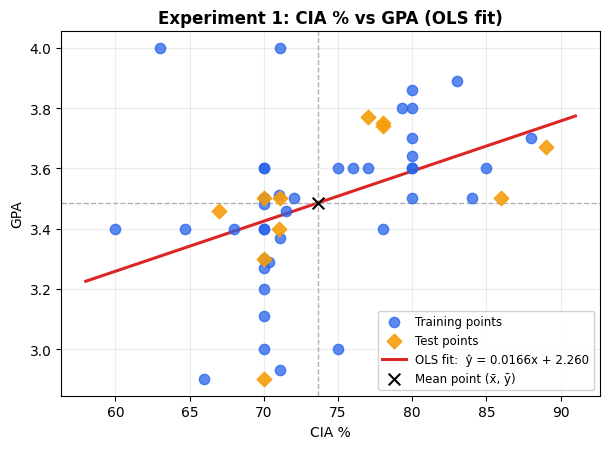

In [43]:
import matplotlib.pyplot as plt

def regression_plot(X_col, y_col, X_train, X_test, y_train, y_test, m, b, label, xlabel, color):
    x_mean, y_mean = np.mean(X_train.flatten()), np.mean(y_train)
    x_all = df[X_col].values
    x_line = np.linspace(x_all.min() - 2, x_all.max() + 2, 100)
    y_line = m * x_line + b

    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    ax.scatter(X_train.flatten(), y_train, color=color, alpha=0.75, s=55, label='Training points', zorder=3)
    ax.scatter(X_test.flatten(), y_test, color='#f59e0b', alpha=0.9, s=55, marker='D', label='Test points', zorder=3)
    ax.plot(x_line, y_line, color='#dc2626', linewidth=2.2, label=f'OLS fit:  ŷ = {m:.4f}x + {b:.3f}', zorder=2)
    ax.axvline(x_mean, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(y_mean, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.scatter([x_mean], [y_mean], color='black', s=70, marker='x', zorder=4, label='Mean point (x̄, ȳ)')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('GPA')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8.5, framealpha=0.9)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

regression_plot('cia_percent', 'gpa', X1_train, X1_test, y1_train, y1_test, m1_manual, b1_manual,
                 'Experiment 1: CIA % vs GPA (OLS fit)', 'CIA %', color='#2563eb')

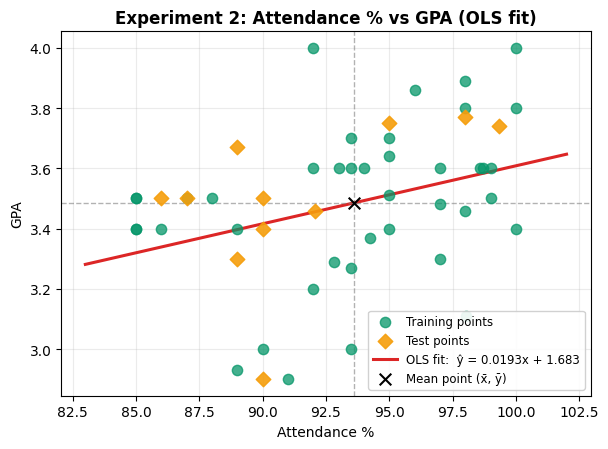

In [44]:
regression_plot('attendance_percent', 'gpa', X2_train, X2_test, y2_train, y2_test, m2_manual, b2_manual,
                 'Experiment 2: Attendance % vs GPA (OLS fit)', 'Attendance %', color='#059669')

**How to read these:** the dashed grey lines mark the mean CIA/Attendance (x̄) and mean GPA (ȳ). OLS finds the line that passes through the mean point (x̄, ȳ) while minimizing the squared vertical distance to every point. The diagrams below zoom into *why* the formula looks the way it does.

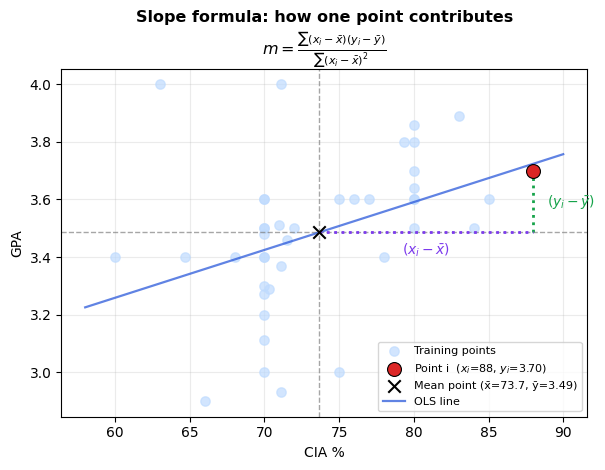

In [45]:
# ---- Diagram: how one point contributes to the slope formula ----
x_all, y_all = X1_train.flatten(), y1_train
x_mean, y_mean = np.mean(x_all), np.mean(y_all)
idx = np.argmax(x_all)
xi, yi = x_all[idx], y_all[idx]

fig, ax = plt.subplots(figsize=(6.2, 4.8))
ax.scatter(x_all, y_all, color='#bfdbfe', alpha=0.7, s=45, zorder=2, label='Training points')
ax.scatter([xi], [yi], color='#dc2626', s=100, zorder=5, edgecolor='black', linewidth=0.8,
           label=f'Point i  ($x_i$={xi:.0f}, $y_i$={yi:.2f})')
ax.scatter([x_mean], [y_mean], color='black', s=80, marker='x', zorder=5,
           label=f'Mean point (x̄={x_mean:.1f}, ȳ={y_mean:.2f})')
ax.axvline(x_mean, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y_mean, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.plot([xi, xi], [y_mean, yi], color='#16a34a', linestyle=':', linewidth=2, zorder=4)
ax.plot([x_mean, xi], [y_mean, y_mean], color='#7c3aed', linestyle=':', linewidth=2, zorder=4)
ax.annotate(r'$(x_i - \bar{x})$', xy=((xi + x_mean) / 2, y_mean), xytext=(0, -16),
            textcoords='offset points', ha='center', fontsize=10, color='#7c3aed', fontweight='bold')
ax.annotate(r'$(y_i - \bar{y})$', xy=(xi, (yi + y_mean) / 2), xytext=(10, 0),
            textcoords='offset points', va='center', fontsize=10, color='#16a34a', fontweight='bold')

x_line = np.linspace(x_all.min() - 2, x_all.max() + 2, 100)
ax.plot(x_line, m1_manual * x_line + b1_manual, color='#1d4ed8', linewidth=1.6, alpha=0.7, label='OLS line')
ax.set_xlabel('CIA %'); ax.set_ylabel('GPA')
ax.set_title('Slope formula: how one point contributes\n' + r'$m = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}$',
             fontsize=11.5, fontweight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()

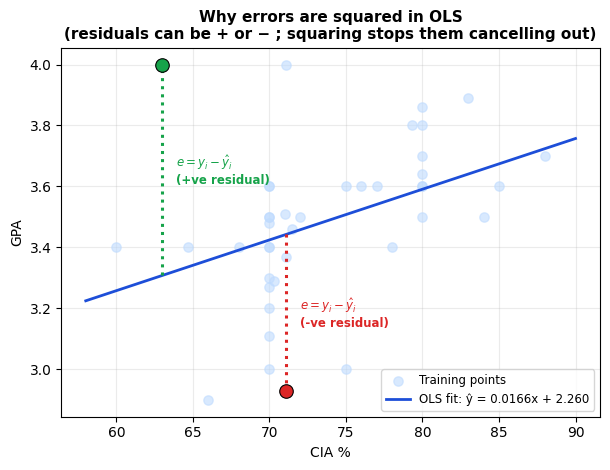

In [46]:
# ---- Diagram: why OLS squares the residuals ----
idx_neg = np.argmin(y_all - (m1_manual * x_all + b1_manual))
idx_pos = np.argmax(y_all - (m1_manual * x_all + b1_manual))

fig, ax = plt.subplots(figsize=(6.2, 4.8))
ax.scatter(x_all, y_all, color='#bfdbfe', alpha=0.6, s=45, zorder=2, label='Training points')
ax.plot(x_line, m1_manual * x_line + b1_manual, color='#1d4ed8', linewidth=2, zorder=3,
        label=f'OLS fit: ŷ = {m1_manual:.4f}x + {b1_manual:.3f}')

for idx, color, sign in [(idx_neg, '#dc2626', '-'), (idx_pos, '#16a34a', '+')]:
    xi, yi = x_all[idx], y_all[idx]
    yhat = m1_manual * xi + b1_manual
    ax.scatter([xi], [yi], color=color, s=95, zorder=5, edgecolor='black', linewidth=0.8)
    ax.plot([xi, xi], [yhat, yi], color=color, linestyle=':', linewidth=2.2, zorder=4)
    mid = (yi + yhat) / 2
    ax.annotate(rf'$e = y_i-\hat{{y}}_i$' + '\n' + f'({sign}ve residual)', xy=(xi, mid), xytext=(10, 0),
                textcoords='offset points', va='center', fontsize=8.5, color=color, fontweight='bold')

ax.set_xlabel('CIA %'); ax.set_ylabel('GPA')
ax.set_title('Why errors are squared in OLS\n(residuals can be + or \u2212 ; squaring stops them cancelling out)',
             fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=8.5); ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()

## Comparison Task: Scikit-learn vs Manual OLS

In [47]:
comp1 = pd.DataFrame({
    'CIA_%': X1_test.flatten(),
    'Actual_GPA': y1_test,
    'sklearn_pred': y1_pred_sklearn,
    'manual_OLS_pred': y1_pred_manual,
    'abs_diff': np.abs(y1_pred_sklearn - y1_pred_manual)
})
print("Experiment 1 - CIA % -> GPA")
comp1

Experiment 1 - CIA % -> GPA


,CIA_%,Actual_GPA,sklearn_pred,manual_OLS_pred,abs_diff
0,67.00,3.46,3.374802,3.374802,0.0
1,70.00,3.30,3.424699,3.424699,0.0
2,78.00,3.74,3.557757,3.557757,0.0
3,70.00,2.90,3.424699,3.424699,0.0
4,77.00,3.77,3.541125,3.541125,0.0
5,71.11,3.50,3.443161,3.443161,0.0
6,78.00,3.75,3.557757,3.557757,0.0
7,86.00,3.50,3.690815,3.690815,0.0
8,70.00,3.50,3.424699,3.424699,0.0
9,71.00,3.40,3.441331,3.441331,0.0


In [48]:
comp2 = pd.DataFrame({
    'Attendance_%': X2_test.flatten(),
    'Actual_GPA': y2_test,
    'sklearn_pred': y2_pred_sklearn,
    'manual_OLS_pred': y2_pred_manual,
    'abs_diff': np.abs(y2_pred_sklearn - y2_pred_manual)
})
print("Experiment 2 - Attendance % -> GPA")
comp2

Experiment 2 - Attendance % -> GPA


,Attendance_%,Actual_GPA,sklearn_pred,manual_OLS_pred,abs_diff
0,92.08,3.46,3.455956,3.455956,0.0
1,89.00,3.30,3.396648,3.396648,0.0
2,99.34,3.74,3.595753,3.595753,0.0
3,90.00,2.90,3.415904,3.415904,0.0
4,97.99,3.77,3.569757,3.569757,0.0
5,90.00,3.50,3.415904,3.415904,0.0
6,95.00,3.75,3.512183,3.512183,0.0
7,86.00,3.50,3.338881,3.338881,0.0
8,87.00,3.50,3.358137,3.358137,0.0
9,90.00,3.40,3.415904,3.415904,0.0


In [49]:
print(f"Experiment 1 max |sklearn - manual| difference: {comp1['abs_diff'].max():.10f}")
print(f"Experiment 2 max |sklearn - manual| difference: {comp2['abs_diff'].max():.10f}")

Experiment 1 max |sklearn - manual| difference: 0.0000000000
Experiment 2 max |sklearn - manual| difference: 0.0000000000


**Observation:** the sklearn predictions and the manually-computed OLS predictions are identical (difference ≈ 0, down to floating-point precision). This is expected — Scikit-learn's `LinearRegression` *also* solves ordinary least squares internally for a single feature, so both approaches converge on the same slope and intercept.

## Parameter Saving Task (Pickle)

In [50]:
params = {
    'experiment_1_cia_to_gpa': {'slope': float(m1_sklearn), 'intercept': float(b1_sklearn)},
    'experiment_2_attendance_to_gpa': {'slope': float(m2_sklearn), 'intercept': float(b2_sklearn)}
}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(params, f)

print("Saved parameters:", params)

Saved parameters: {'experiment_1_cia_to_gpa': {'slope': 0.016632253972474607, 'intercept': 2.260441418659288}, 'experiment_2_attendance_to_gpa': {'slope': 0.019255770916074652, 'intercept': 1.6828844829346514}}


In [51]:
# Load the pickle file back
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

print("Loaded parameters:", loaded_params)

Loaded parameters: {'experiment_1_cia_to_gpa': {'slope': 0.016632253972474607, 'intercept': 2.260441418659288}, 'experiment_2_attendance_to_gpa': {'slope': 0.019255770916074652, 'intercept': 1.6828844829346514}}


In [52]:
# Use the loaded parameters to make a prediction
m_loaded = loaded_params['experiment_1_cia_to_gpa']['slope']
b_loaded = loaded_params['experiment_1_cia_to_gpa']['intercept']

sample_cia = 75   # example: a student with 75% CIA
predicted_gpa = m_loaded * sample_cia + b_loaded
print(f"Predicted GPA for CIA = {sample_cia}% (using loaded parameters): {predicted_gpa:.3f}")

Predicted GPA for CIA = 75% (using loaded parameters): 3.508


## Final Observations and Inference

1. **Both methods agree exactly.** Scikit-learn's `LinearRegression` and the manually-derived OLS formulas produced identical slope, intercept, and predictions — confirming sklearn uses OLS under the hood for simple linear regression.
2. **CIA % is a weak-to-moderate predictor of GPA** (R² ≈ 0.25 on the test split): higher CIA scores trend with higher GPA, but a lot of variation in GPA is left unexplained — other factors (study habits, course difficulty, etc.) likely matter too.
3. **Attendance % is an even weaker predictor of GPA** (R² ≈ 0.18 here): attending more classes correlates only loosely with a higher GPA in this sample.
4. **Data quality mattered a lot.** The raw survey export had inconsistent formats (`%` signs, placeholder text like `"Option 1"`, swapped fields, mixed salary formats) — the preprocessing step was essential before any modeling could be trusted.
5. **Sample size is small** (52 valid responses after removing duplicate submissions), so these regression coefficients should be treated as indicative, not definitive — a larger class sample would give more reliable estimates.

*Note: exact slope/intercept values depend on the `random_state` used in `train_test_split` and on the median-imputation choice for missing values — re-running with different students' data will shift these numbers slightly.*